## Statistical Evidence and Business Significance

## Business Question

**What evidence supports the decision to implement the new Vanguard website?**

This analysis compares customer behaviour in the Control and Test groups. It evaluates whether the observed KPI differences are statistically significant and whether their magnitudes are meaningful from a business perspective.

In [1]:
import os
print (os.getcwd())

C:\Users\LENOVO\ironhack\Week_6\Week_6_project


In [2]:
import pandas as pd
import numpy as np

journey_kpis = pd.read_csv("journey_kpis.csv")

print("Journey KPI shape:", journey_kpis.shape)
journey_kpis.head()

Journey KPI shape: (159112, 42)


,client_id,visit_id,visitor_id,number_of_visitors,journey_start,journey_end,number_of_events,journey_sequence,number_of_starts,number_of_confirms,...,repeated_step_errors,step_back_errors,has_navigation_error,valid_completion,abandoned,furthest_stage_reached,navigation_error_rate_percent,step_back_rate_percent,repeated_step_rate_percent,abandonment_eligible
0,169,749567106_99161211863_557568,201385055_71273495308,1,2017-04-12 20:19:36,2017-04-12 20:23:09,5,"['start', 'step_1', 'step_2', 'step_3', 'confi...",1,1,...,0,0,False,True,False,Step 3,0.0,0.0,0.0,True
1,336,649044751_80905125055_554468,64757908_3400128256,1,2017-06-01 07:26:55,2017-06-01 07:42:43,2,"['start', 'start']",2,0,...,1,0,True,False,True,Start only,100.0,0.0,100.0,True
2,546,731811517_9330176838_94847,475037402_89828530214,1,2017-06-17 10:03:29,2017-06-17 10:05:42,5,"['start', 'step_1', 'step_2', 'step_3', 'confi...",1,1,...,0,0,False,True,False,Step 3,0.0,0.0,0.0,True
3,555,637149525_38041617439_716659,402506806_56087378777,1,2017-04-15 12:57:56,2017-04-15 13:00:34,5,"['start', 'step_1', 'step_2', 'step_3', 'confi...",1,1,...,0,0,False,True,False,Step 3,0.0,0.0,0.0,True
4,647,40369564_40101682850_311847,66758770_53988066587,1,2017-04-12 15:41:28,2017-04-12 15:47:45,5,"['start', 'step_1', 'step_2', 'step_3', 'confi...",1,1,...,0,0,False,True,False,Step 3,0.0,0.0,0.0,True


In [3]:
journey_kpis.to_csv(
    r"C:\Users\LENOVO\Ironhack\Week_6\Week_6_Project\journey_kpis.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [4]:
journey_kpis.info()

<class 'pandas.DataFrame'>
RangeIndex: 159112 entries, 0 to 159111
Data columns (total 42 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   client_id                         159112 non-null  int64  
 1   visit_id                          159112 non-null  str    
 2   visitor_id                        159112 non-null  str    
 3   number_of_visitors                159112 non-null  int64  
 4   journey_start                     159112 non-null  str    
 5   journey_end                       159112 non-null  str    
 6   number_of_events                  159112 non-null  int64  
 7   journey_sequence                  159112 non-null  str    
 8   number_of_starts                  159112 non-null  int64  
 9   number_of_confirms                159112 non-null  int64  
 10  repeated_steps                    159112 non-null  int64  
 11  step_backs                        159112 non-null  int64  
 12 

In [5]:
experiment_df = pd.read_csv(
    r"C:\Users\LENOVO\Ironhack\Week_6\Week_6_Project\Data set\df_final_experiment_clients.txt"
)

print(experiment_df.shape)

(70609, 2)


## Preparing the Control and Test Journey Dataset

The customer-journey KPI dataset contains one row for each client visit, while the experiment dataset identifies whether each client belongs to the Control or Test group.

These datasets are merged using `client_id` so that every journey can be compared according to the client's experimental group.

Only clients assigned to Control or Test are retained. The merge is validated as `many-to-one` because one client may have multiple journeys, but each client must belong to only one experimental group.

In [6]:
# Keep only clients assigned to Control or Test
experiment_groups = experiment_df.dropna(
    subset=["Variation"]
)[["client_id", "Variation"]].drop_duplicates("client_id")

# Add the experimental group to every customer journey
journey_ab = journey_kpis.merge(
    experiment_groups,
    on="client_id",
    how="inner",
    validate="many_to_one"
)

print("Journey analysis shape:", journey_ab.shape)
print("\nJourneys by group:")
print(journey_ab["Variation"].value_counts())

print("\nUnique clients by group:")
print(
    journey_ab.groupby("Variation")["client_id"].nunique()
)

Journey analysis shape: (69447, 43)

Journeys by group:
Variation
Test       37204
Control    32243
Name: count, dtype: int64

Unique clients by group:
Variation
Control    23532
Test       26968
Name: client_id, dtype: int64


### Merge Validation

The merged dataset contains **69,447 customer journeys** belonging to **50,500 experiment clients**.

- Control: 32,243 journeys from 23,532 clients
- Test: 37,204 journeys from 26,968 clients

The unique-client totals match the original experiment assignment. This confirms that all Control and Test clients were retained and that each client is associated with only one experimental group.

The number of journeys is greater than the number of clients because some clients completed more than one website visit.

## 1. Exploratory Comparison of Customer Behaviour

Before conducting statistical tests, the main KPIs are compared descriptively between the Control and Test groups.

This initial comparison helps identify:

- Whether the redesigned website increased successful completion.
- Whether customers completed the process more quickly.
- Whether the new design reduced navigation errors.
- Whether customers moved backwards through the process less frequently.

At this stage, observed differences are descriptive and should not yet be interpreted as statistically significant.

In [7]:
kpi_comparison = (
    journey_ab.groupby("Variation")
    .agg(
        journeys=("visit_id", "count"),
        unique_clients=("client_id", "nunique"),
        completion_rate=("valid_completion", "mean"),
        median_completion_time=("completion_time_minutes", "median"),
        median_effective_time=("effective_time_minutes", "median"),
        navigation_error_rate=("has_navigation_error", "mean"),
        journeys_with_step_backs=("step_backs", lambda x: (x > 0).mean()),
        average_step_backs=("step_backs", "mean")
    )
    .reset_index()
)

# Convert proportions into percentages
percentage_columns = [
    "completion_rate",
    "navigation_error_rate",
    "journeys_with_step_backs"
]

kpi_comparison[percentage_columns] = (
    kpi_comparison[percentage_columns] * 100
)

kpi_comparison.round(2)

,Variation,journeys,unique_clients,completion_rate,median_completion_time,median_effective_time,navigation_error_rate,journeys_with_step_backs,average_step_backs
0,Control,32243,23532,46.29,4.08,3.87,37.29,20.23,0.30
1,Test,37204,26968,48.22,3.32,3.20,44.92,26.80,0.44


### Initial Behavioural Comparison

The exploratory KPI comparison shows both improvements and disadvantages in the Test experience.

#### Observed improvements

- Journey-level completion increased from **46.29% in Control to 48.22% in Test**, an increase of **1.93 percentage points**.
- Median completion time decreased from **4.08 minutes to 3.32 minutes**, meaning the typical completed Test journey was approximately **0.76 minutes faster**.
- Median effective time decreased from **3.87 minutes to 3.20 minutes**, suggesting that Test customers moved forward through the process more quickly.

#### Observed disadvantages

- The navigation error rate increased from **37.29% in Control to 44.92% in Test**, an increase of **7.63 percentage points**.
- Journeys containing step backs increased from **20.23% to 26.80%**.
- Average step backs increased from **0.30 per Control journey to 0.44 per Test journey**.

The initial evidence therefore suggests that the redesigned website helped customers complete the process more quickly and produced a modest improvement in journey completion. However, Test customers also encountered substantially more navigation errors and backward movements.

These results are descriptive. Statistical tests are still required to determine whether the differences are greater than would reasonably be expected by chance.

### Funnel Progression by Experimental Group

Funnel progression measures the percentage of journeys that reached each stage of the online process.

Comparing the stages helps identify where customers leave the process and whether the redesigned website improved or weakened progression at particular points.

In [8]:
funnel_columns = [
    "reached_start",
    "reached_step_1",
    "reached_step_2",
    "reached_step_3",
    "reached_confirm"
]

funnel_progression = (
    journey_ab.groupby("Variation")[funnel_columns]
    .mean()
    .mul(100)
    .T
    .reset_index()
    .rename(columns={"index": "funnel_stage"})
)

funnel_progression["difference_pp"] = (
    funnel_progression["Test"]
    - funnel_progression["Control"]
)

funnel_progression.round(2)

Variation,funnel_stage,Control,Test,difference_pp
0,reached_start,96.03,89.29,-6.74
1,reached_step_1,72.29,75.42,3.12
2,reached_step_2,61.38,64.86,3.48
3,reached_step_3,55.13,58.07,2.95
4,reached_confirm,45.98,48.10,2.12


### Funnel Denominator Validation

Across all recorded journeys, **96.03% of Control journeys** and **89.29% of Test journeys** contain a recorded 'start' 'event'.

Some journeys begin in the available data at a later funnel stage. Therefore, the lower recorded-start percentage in Test does not necessarily mean customers abandoned before starting; it may reflect incomplete event capture or customers continuing an earlier journey.

To create a logically comparable funnel, the main funnel analysis is restricted to journeys containing a recorded 'start'. The missing-start difference will be retained as a data limitation.

In [9]:
# Restrict the funnel analysis to journeys with a recorded start
started_journeys = journey_ab[
    journey_ab["has_recorded_start"]
].copy()

started_funnel = (
    started_journeys.groupby("Variation")[funnel_columns]
    .mean()
    .mul(100)
    .T
    .reset_index()
    .rename(columns={"index": "funnel_stage"})
)

started_funnel["difference_pp"] = (
    started_funnel["Test"]
    - started_funnel["Control"]
)

print("Started journeys by group:")
print(started_journeys["Variation"].value_counts())

started_funnel.round(2)

Started journeys by group:
Variation
Test       33219
Control    30962
Name: count, dtype: int64


Variation,funnel_stage,Control,Test,difference_pp
0,reached_start,100.00,100.00,0.00
1,reached_step_1,75.28,84.46,9.18
2,reached_step_2,63.92,72.64,8.72
3,reached_step_3,57.41,65.04,7.64
4,reached_confirm,47.88,53.87,5.99


### Funnel Progression Findings

Among journeys with a recorded starting point, the Test group progressed further through every stage of the funnel.

- Progression from `start` to `step_1` was **84.46% for Test**, compared with **75.28% for Control**. This was the largest difference: **9.18 percentage points**.
- Test also maintained higher reach rates at `step_2` and `step_3`.
- **53.87% of Test journeys** reached `confirm`, compared with **47.88% of Control journeys**, a difference of **5.99 percentage points**.

The Test advantage is largest near the beginning of the process and gradually decreases toward confirmation. This suggests that the redesigned website is particularly effective at encouraging customers to move beyond the starting page, although some of this early advantage is lost during later stages.

`reached_confirm` records whether a journey contained a confirm event. It is different from `valid_completion`, which applies stricter journey-order requirements. This explains why these percentages differ from the earlier valid-completion rates.

### Visual Comparison of Funnel Progression

The funnel progression chart compares the percentage of started journeys reaching each stage. It makes the size and consistency of the difference between Control and Test easier to identify than the summary table alone.

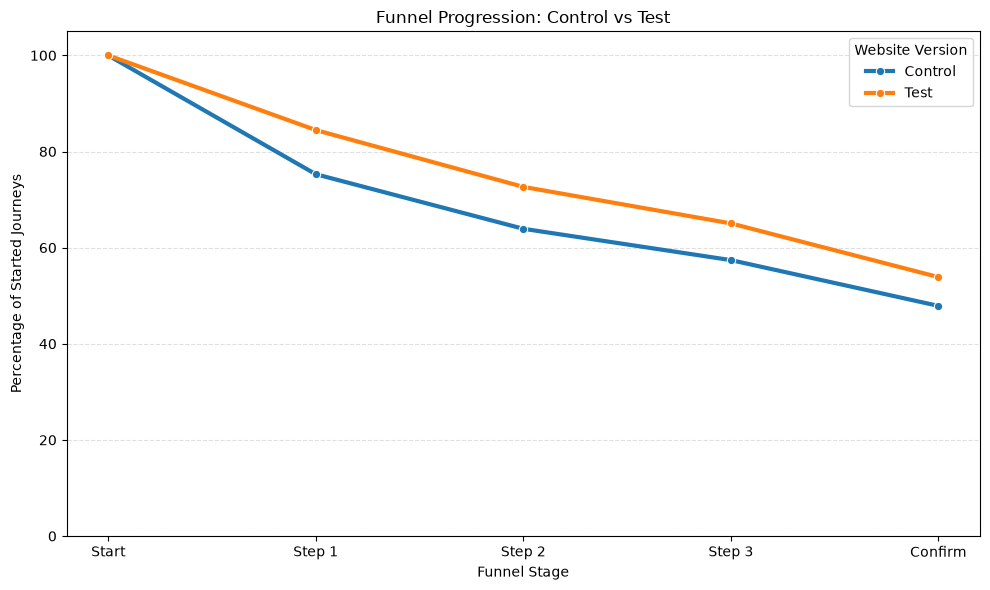

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the funnel table for plotting
funnel_plot_data = started_funnel.melt(
    id_vars="funnel_stage",
    value_vars=["Control", "Test"],
    var_name="Variation",
    value_name="reach_rate_percent"
)

stage_names = {
    "reached_start": "Start",
    "reached_step_1": "Step 1",
    "reached_step_2": "Step 2",
    "reached_step_3": "Step 3",
    "reached_confirm": "Confirm"
}

funnel_plot_data["funnel_stage"] = (
    funnel_plot_data["funnel_stage"].map(stage_names)
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=funnel_plot_data,
    x="funnel_stage",
    y="reach_rate_percent",
    hue="Variation",
    marker="o",
    linewidth=3
)

plt.title("Funnel Progression: Control vs Test")
plt.xlabel("Funnel Stage")
plt.ylabel("Percentage of Started Journeys")
plt.ylim(0, 105)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Website Version")
plt.tight_layout()
plt.show()

### Interpretation of Funnel Progression

Both groups experience customer loss as journeys move through the funnel. However, the Test group remains above the Control group at every stage after `start`.

The largest separation appears at `step_1`, where **84.46% of Test journeys** progressed compared with **75.28% of Control journeys**. By the confirmation stage, the difference narrows but remains favourable to Test: **53.87% versus 47.88%**.

This visual evidence suggests that the redesigned website improved overall funnel progression. However, neither group retained all customers, and approximately **46% of started Test journeys** still failed to reach confirmation. The next analysis examines consecutive stage conversion to locate the greatest point of customer friction.

In [11]:
stage_labels = [
    "Start → Step 1",
    "Step 1 → Step 2",
    "Step 2 → Step 3",
    "Step 3 → Confirm"
]

stage_columns = [
    "reached_start",
    "reached_step_1",
    "reached_step_2",
    "reached_step_3",
    "reached_confirm"
]

conversion_rows = []

for variation in ["Control", "Test"]:
    group = started_journeys[
        started_journeys["Variation"] == variation
    ]

    stage_counts = group[stage_columns].sum()

    for i, transition in enumerate(stage_labels):
        conversion_rate = (
            stage_counts.iloc[i + 1]
            / stage_counts.iloc[i]
            * 100
        )

        conversion_rows.append({
            "Variation": variation,
            "transition": transition,
            "conversion_rate_percent": conversion_rate
        })

consecutive_conversion = pd.DataFrame(conversion_rows)

conversion_comparison = consecutive_conversion.pivot(
    index="transition",
    columns="Variation",
    values="conversion_rate_percent"
).reset_index()

conversion_comparison["difference_pp"] = (
    conversion_comparison["Test"]
    - conversion_comparison["Control"]
)

conversion_comparison.round(2)

Variation,transition,Control,Test,difference_pp
0,Start → Step 1,75.28,84.46,9.18
1,Step 1 → Step 2,84.91,86.00,1.09
2,Step 2 → Step 3,89.80,89.54,-0.27
3,Step 3 → Confirm,83.41,82.83,-0.58


### Consecutive Funnel Conversion Findings

The largest behavioural difference occurs during the transition from `Start` to `Step 1`.

- **Start → Step 1:** Test outperformed Control by **9.18 percentage points**.
- **Step 1 → Step 2:** Test had a smaller advantage of **1.09 percentage points**.
- **Step 2 → Step 3:** Test was **0.27 percentage points lower** than Control.
- **Step 3 → Confirm:** Test was **0.58 percentage points lower** than Control.

The redesigned website therefore appears especially effective at encouraging customers to begin the process. However, it does not improve every individual transition. Control performs slightly better during the final two transitions.

The early Test advantage is large enough to produce a higher overall confirmation rate despite its slightly weaker later-stage conversion. For the Test group, the greatest remaining friction occurs between `Step 3` and `Confirm`, where approximately **17.17%** of customers reaching Step 3 fail to reach confirmation.

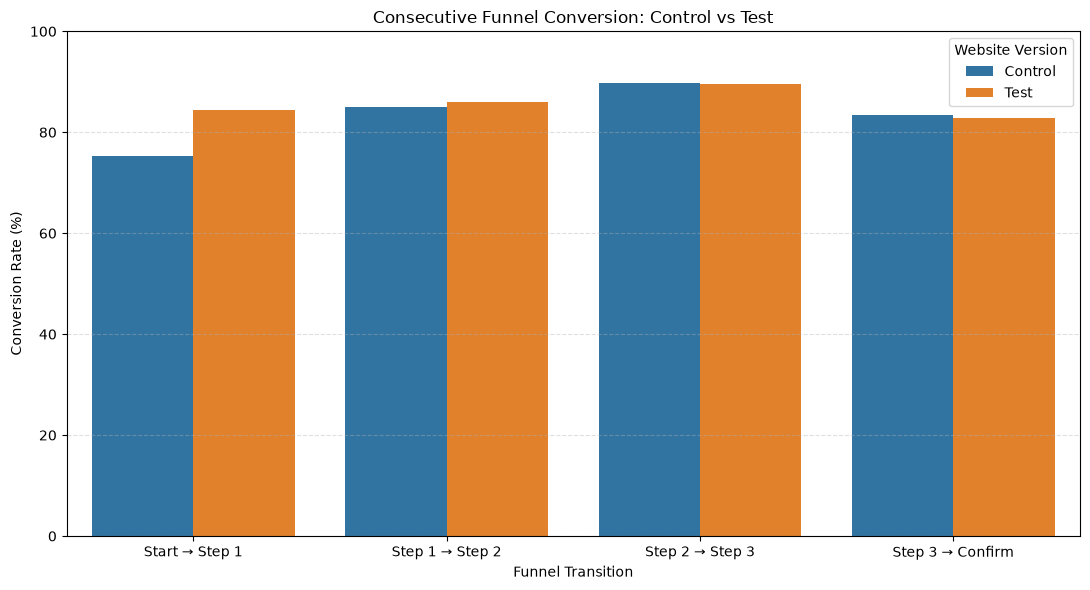

In [12]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=consecutive_conversion,
    x="transition",
    y="conversion_rate_percent",
    hue="Variation"
)

plt.title("Consecutive Funnel Conversion: Control vs Test")
plt.xlabel("Funnel Transition")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Website Version")
plt.tight_layout()
plt.show()

### Completion-Time Distribution

Completion time measures the number of minutes between the recorded start of a journey and its valid confirmation.

Only valid completed journeys are included because incomplete journeys do not have a complete start-to-confirm duration.

The mean, median, standard deviation and percentiles are examined to identify differences between Control and Test and determine whether the distributions are skewed or affected by extreme values.

In [13]:
completed_journeys = journey_ab[
    journey_ab["valid_completion"]
    & journey_ab["completion_time_minutes"].notna()
].copy()

completion_time_descriptive = (
    completed_journeys.groupby("Variation")[
        "completion_time_minutes"
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .round(2)
)

print("Valid completed journeys by group:")
print(completed_journeys["Variation"].value_counts())

completion_time_descriptive

Valid completed journeys by group:
Variation
Test       17941
Control    14925
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
Variation,,,,,,,,,,,
Control,14925.0,5.39,4.39,0.55,2.65,4.08,6.50,10.55,13.93,22.45,71.55
Test,17941.0,4.74,4.78,0.08,2.20,3.32,5.43,9.22,12.83,24.43,105.45


### Completion-Time Descriptive Findings

The Test group completed the process faster on average and at the median:

- Median completion time decreased from **4.08 minutes in Control to 3.32 minutes in Test**, an improvement of **0.76 minutes**, or approximately **46 seconds**.
- Mean completion time decreased from **5.39 minutes to 4.74 minutes**, an improvement of **0.65 minutes**, or approximately **39 seconds**.

For both groups, the mean is higher than the median, indicating that unusually long journeys pull the average upward.

The Test group also has a larger maximum completion time and a slightly higher 99th percentile. This suggests that although the typical Test customer completed faster, a small number of Test journeys experienced very long delays.

The distribution shape and outliers must be examined before selecting the statistical test.

Completion-time skewness:
Variation
Control    2.98
Test       4.84
Name: completion_time_minutes, dtype: float64


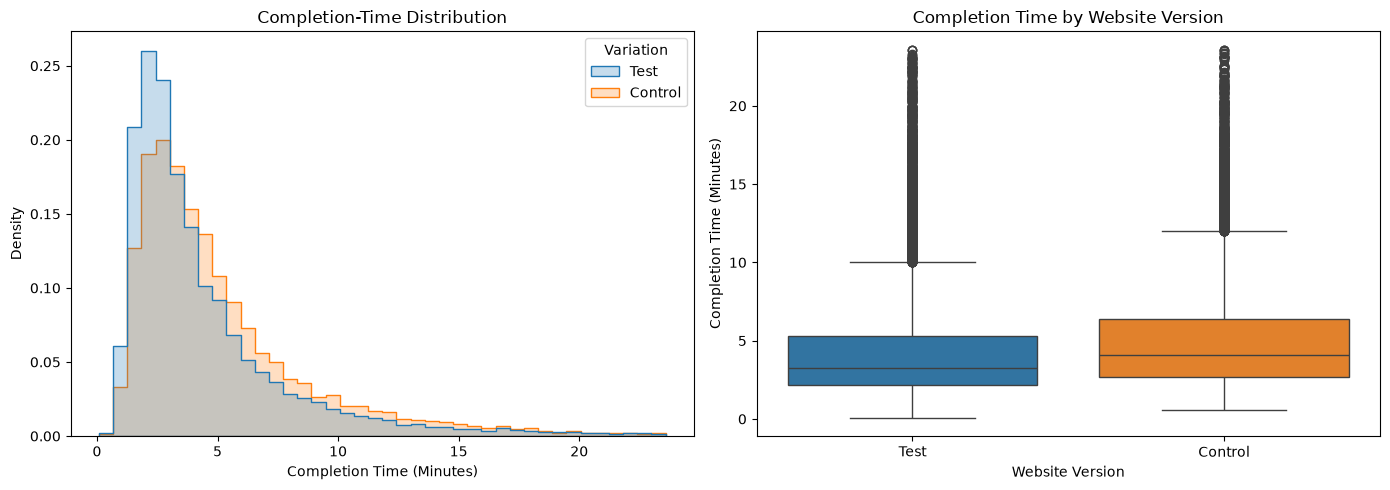

In [14]:
print("Completion-time skewness:")

print(
    completed_journeys.groupby("Variation")[
        "completion_time_minutes"
    ].skew().round(2)
)

# Limit the visual to the 99th percentile so extreme values
# do not compress the main part of the distribution
time_limit = completed_journeys[
    "completion_time_minutes"
].quantile(0.99)

completion_time_plot = completed_journeys[
    completed_journeys["completion_time_minutes"] <= time_limit
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=completion_time_plot,
    x="completion_time_minutes",
    hue="Variation",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    ax=axes[0]
)

axes[0].set_title("Completion-Time Distribution")
axes[0].set_xlabel("Completion Time (Minutes)")
axes[0].set_ylabel("Density")

sns.boxplot(
    data=completion_time_plot,
    x="Variation",
    y="completion_time_minutes",
    hue="Variation",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Completion Time by Website Version")
axes[1].set_xlabel("Website Version")
axes[1].set_ylabel("Completion Time (Minutes)")

plt.tight_layout()
plt.show()

The box plot visualises the completion-time IQR and potential outliers. The box represents the middle 50% of observations, while the line inside the box represents the median. Individual points beyond the upper whiskers are potential high-duration outliers.

Both groups contain customers who took substantially longer than the typical completion time. These observations are retained because they may represent genuine cases of customer friction rather than data errors.

### Interquartile Range of Completion Time

The interquartile range (IQR) measures the spread of the middle 50% of completion times.

\[
IQR = Q3 - Q1
\]

The IQR is more appropriate than the standard deviation for this analysis because completion times are strongly skewed and contain extreme values. It is also used to identify potential outliers using the standard \(1.5 \times IQR\) rule.

The IQR method identifies completion times above **12.28 minutes for Control** and **10.32 minutes for Test** as potential outliers. These observations are retained because they may represent genuine customer experiences rather than data errors. Removing them could hide cases where customers experienced substantial difficulty. The Mann–Whitney U test is appropriate because it is based on ranks and is less sensitive to extreme values.

### Interpretation of Completion-Time Distribution

The redesigned website appears to reduce completion time for the typical customer.

The Test distribution is concentrated further to the left than the Control distribution, indicating that a larger proportion of Test journeys were completed within fewer minutes. The box plot supports this result: the Test median is **3.32 minutes**, compared with **4.08 minutes** for Control. This represents a reduction of approximately **46 seconds** in the typical completion journey.

Both distributions are strongly right-skewed:

- Control skewness: **2.98**
- Test skewness: **4.84**

A positive right skew means that most customers completed within a relatively short time, while a smaller number took substantially longer. The higher Test skewness indicates that the Test group has more extreme long-duration journeys relative to its typical completion time.

Therefore, the redesigned website appears faster for most customers, but some Test customers still experienced unusually long completion times. Because the distributions are non-normal and contain many outliers, the median is more representative than the mean, and a non-parametric Mann–Whitney U test is more appropriate for the statistical comparison.

For visual readability, the graphs are limited to the 99th percentile. All valid completion times, including extreme observations, will remain included in the statistical test.

,count,mean,median,standard_deviation,minimum,maximum
Variation,,,,,,
Control,14925,5.39,4.08,4.39,0.55,71.55
Test,17941,4.74,3.32,4.78,0.08,105.45


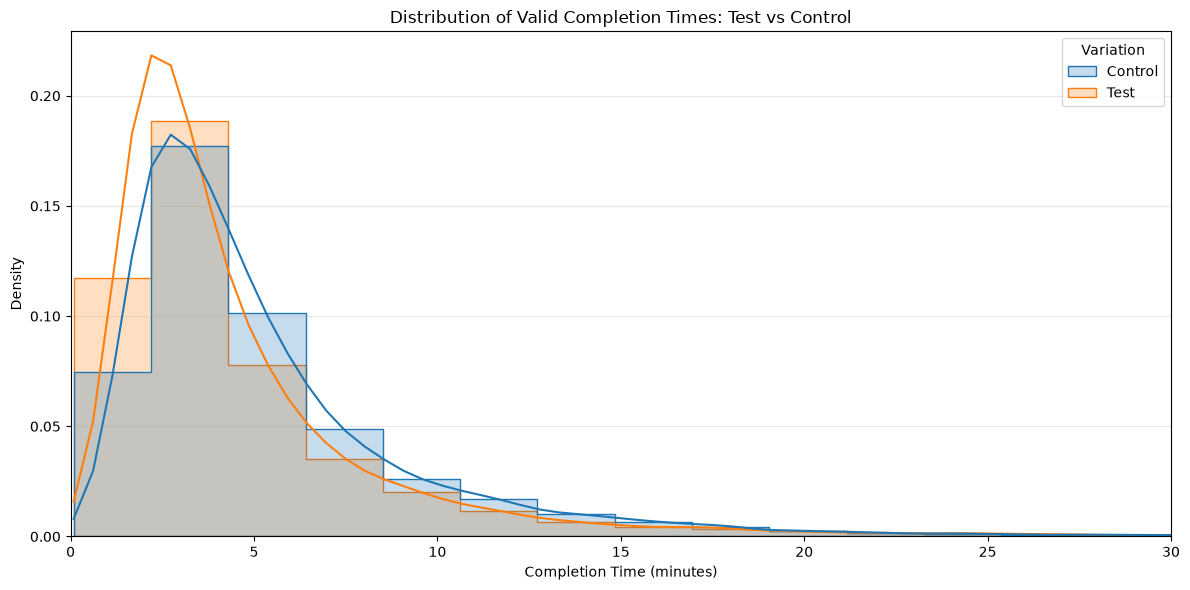

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load journey-level KPI data
journey_kpis = pd.read_csv(
    r"C:\Users\LENOVO\Ironhack\Week_6\Week_6_Project\journey_kpis.csv"
)

# 2. Load experimental-group assignments
experiment = pd.read_csv(
    r"C:\Users\LENOVO\Ironhack\Week_6\Week_6_Project\Data set\df_final_experiment_clients.txt"
)

# 3. Keep only Test and Control clients
experiment_analysis = (
    experiment[
        experiment["Variation"].isin(["Test", "Control"])
    ]
    .drop_duplicates(subset="client_id")
    .copy()
)

# 4. Add experimental group to journey-level data
completion_data = journey_kpis.merge(
    experiment_analysis[["client_id", "Variation"]],
    on="client_id",
    how="inner",
    validate="many_to_one"
)

# 5. Keep only valid completion times
completion_data = completion_data[
    completion_data["valid_completion"].eq(True)
    & completion_data["completion_time_minutes"].notna()
].copy()

# 6. Display descriptive statistics
completion_summary = (
    completion_data
    .groupby("Variation")["completion_time_minutes"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max"
    )
)

display(completion_summary.round(2))

# 7. Plot completion-time distributions
plt.figure(figsize=(12, 6))

sns.histplot(
    data=completion_data,
    x="completion_time_minutes",
    hue="Variation",
    hue_order=["Control", "Test"],
    bins=50,
    kde=True,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Distribution of Valid Completion Times: Test vs Control")
plt.xlabel("Completion Time (minutes)")
plt.ylabel("Density")
plt.xlim(0, 30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Calculate completion-time quartiles and IQR
completion_iqr = (
    completion_data
    .groupby("Variation")["completion_time_minutes"]
    .agg(
        Q1=lambda x: x.quantile(0.25),
        median="median",
        Q3=lambda x: x.quantile(0.75)
    )
)

completion_iqr["IQR"] = (
    completion_iqr["Q3"] - completion_iqr["Q1"]
)

completion_iqr["lower_bound"] = (
    completion_iqr["Q1"] - 1.5 * completion_iqr["IQR"]
)

completion_iqr["upper_bound"] = (
    completion_iqr["Q3"] + 1.5 * completion_iqr["IQR"]
)

completion_iqr.round(2)

,Q1,median,Q3,IQR,lower_bound,upper_bound
Variation,,,,,,
Control,2.65,4.08,6.50,3.85,-3.13,12.28
Test,2.20,3.32,5.43,3.23,-2.65,10.28


### Interpretation of Completion-Time Distribution and IQR

The completion-time distributions for both groups are strongly right-skewed. Most clients completed the process within a few minutes, while a small number of journeys took considerably longer. Because these extreme values can pull the mean upward, the **median and interquartile range (IQR)** provide a more reliable description of the typical completion experience.

The **Control group had a median completion time of 4.08 minutes**, compared with **3.32 minutes for the Test group**. Therefore, the redesigned Test experience was typically about **0.77 minutes faster**.

The completion-time IQR was **3.85 minutes for Control** and **3.25 minutes for Test**. This means that the middle 50% of Test completion times were less spread out, suggesting that the Test group was not only faster but also slightly more consistent.

Overall, the Test design produced a faster and more consistent completion experience. However, both groups contained long completion-time tails and outliers, supporting the use of the **Mann–Whitney U test**, which does not require completion times to follow a normal distribution.

## 2. Statistical Evidence: Completion Time

### Hypotheses

- **Null hypothesis (\(H_0\))**: The completion-time distributions are the same for Control and Test clients.
- **Alternative hypothesis (\(H_1\))**: The completion-time distributions differ between Control and Test clients.

### Test Selection and Assumptions

Completion times are strongly right-skewed and contain substantial outliers. Therefore, the normality assumption required for a standard independent-samples t-test is not satisfied.

The **Mann–Whitney U test** is used because it does not require normally distributed data.

To support the independence assumption, each client is represented by their median valid completion time. This prevents clients with several completed journeys from receiving more influence than clients with only one completed journey.

The groups are independent because every client is assigned to only one experimental group.

In [17]:
from scipy.stats import mannwhitneyu

# One representative completion time per client
client_completion_time = (
    completed_journeys
    .groupby(["client_id", "Variation"])["completion_time_minutes"]
    .median()
    .reset_index(name="median_completion_time")
)

control_time = client_completion_time.loc[
    client_completion_time["Variation"] == "Control",
    "median_completion_time"
]

test_time = client_completion_time.loc[
    client_completion_time["Variation"] == "Test",
    "median_completion_time"
]

# Two-sided Mann–Whitney U test
u_statistic, p_value = mannwhitneyu(
    control_time,
    test_time,
    alternative="two-sided"
)

# Rank-biserial effect size
rank_biserial = (
    2 * u_statistic / (len(control_time) * len(test_time))
) - 1

print("Control clients:", len(control_time))
print("Test clients:", len(test_time))

print(
    "Control median completion time:",
    round(control_time.median(), 2),
    "minutes"
)

print(
    "Test median completion time:",
    round(test_time.median(), 2),
    "minutes"
)

print(
    "Median difference (Test - Control):",
    round(test_time.median() - control_time.median(), 2),
    "minutes"
)

print("Mann–Whitney U statistic:", round(u_statistic, 2))
print("P-value:", p_value)
print("Rank-biserial effect size:", round(rank_biserial, 3))

Control clients: 14904
Test clients: 17893
Control median completion time: 4.08 minutes
Test median completion time: 3.32 minutes
Median difference (Test - Control): -0.77 minutes
Mann–Whitney U statistic: 154398087.0
P-value: 2.3976868776151904e-134
Rank-biserial effect size: 0.158


### Completion-Time Test Result

The Mann–Whitney U test produced a p-value of approximately **2.40 × 10⁻¹³⁴**, which is far below the significance level of 0.05.

Therefore, the null hypothesis is rejected. There is very strong statistical evidence that completion times differ between Control and Test clients, with Test clients generally completing the process faster.

The median completion time decreased from **4.08 minutes for Control to 3.32 minutes for Test**. This is a reduction of approximately **0.77 minutes**, equivalent to about **46 seconds** or approximately **18.9%** of the Control median.

The rank-biserial effect size is **0.158**. This is a small effect, meaning that the difference is consistent but not large at the individual-client level.

From a business perspective, saving approximately 46 seconds per successful customer may still be meaningful when applied across many customers. However, this benefit should be weighed against the higher navigation-error and step-back rates observed in the Test group.

### Confidence Interval for the Median Difference

A bootstrap confidence interval is used because completion times are strongly skewed. It estimates a range of plausible values for the difference in median completion time between Test and Control clients.

In [18]:
rng = np.random.default_rng(42)

bootstrap_differences = []

for _ in range(2000):
    control_sample = rng.choice(
        control_time,
        size=len(control_time),
        replace=True
    )

    test_sample = rng.choice(
        test_time,
        size=len(test_time),
        replace=True
    )

    median_difference = (
        np.median(test_sample)
        - np.median(control_sample)
    )

    bootstrap_differences.append(median_difference)

ci_lower, ci_upper = np.percentile(
    bootstrap_differences,
    [2.5, 97.5]
)

print(
    "95% bootstrap confidence interval:",
    f"[{ci_lower:.2f}, {ci_upper:.2f}] minutes"
)

95% bootstrap confidence interval: [-0.85, -0.72] minutes


### Completion-Time Confidence Interval Result

The 95% bootstrap confidence interval for the median difference between Test and Control is:

\[
[-0.85,\ -0.72]\text{ minutes}
\]

Because the difference was calculated as **Test − Control**, both values being negative indicate that the Test group completed the process faster.

The interval suggests that the redesigned website reduced the typical completion time by approximately **0.72 to 0.85 minutes**, equivalent to approximately **43 to 51 seconds**.

The interval does not contain zero, supporting the conclusion that the completion-time improvement is unlikely to be explained by random variation. Combined with the Mann–Whitney U test, this provides strong statistical evidence that the redesigned website improved completion speed.

The effect remains practically modest at the individual level, but saving approximately three-quarters of a minute per successful customer could produce meaningful cumulative benefits across a large customer population.

### Effective-Time Comparison

Effective time measures the time associated with forward progression through the customer journey. It reduces the influence of interruptions, repeated steps and backward navigation.

Comparing effective time helps determine whether the redesigned website made the core process itself more efficient, rather than merely changing the total time recorded between start and confirmation.

As with completion time, each client is represented by their median effective time so that clients with multiple journeys do not receive additional statistical weight.

In [19]:
client_effective_time = (
    completed_journeys
    .groupby(["client_id", "Variation"])["effective_time_minutes"]
    .median()
    .reset_index(name="median_effective_time")
)

effective_time_descriptive = (
    client_effective_time
    .groupby("Variation")["median_effective_time"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .round(2)
)

print("Clients with valid effective time:")
print(client_effective_time["Variation"].value_counts())

print("\nEffective-time skewness:")
print(
    client_effective_time.groupby("Variation")[
        "median_effective_time"
    ].skew().round(2)
)

effective_time_descriptive

Clients with valid effective time:
Variation
Test       17893
Control    14904
Name: count, dtype: int64

Effective-time skewness:
Variation
Control    2.53
Test       2.97
Name: median_effective_time, dtype: float64


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
Variation,,,,,,,,,,,
Control,14904.0,5.01,3.86,0.22,2.55,3.87,6.05,9.68,12.80,20.02,55.20
Test,17893.0,4.37,3.72,0.08,2.15,3.20,5.17,8.45,11.49,19.86,44.65


### Effective-Time Descriptive Findings

The redesigned website reduced the time customers spent progressing forward through the required funnel stages.

- Median effective time decreased from **3.87 minutes in Control to 3.20 minutes in Test**.
- This is a reduction of **0.67 minutes**, equivalent to approximately **40 seconds**.
- Mean effective time decreased from **5.01 minutes to 4.37 minutes**.

The Test group also has lower values at the 75th, 90th, 95th and 99th percentiles. This suggests that its improvement is visible across most of the effective-time distribution, not only at the median.

Both distributions are strongly right-skewed:

- Control skewness: **2.53**
- Test skewness: **2.97**

Therefore, the median and IQR are more representative than the mean and standard deviation. A Mann–Whitney U test will again be used for statistical comparison.

In [20]:
effective_time_iqr = (
    client_effective_time
    .groupby("Variation")["median_effective_time"]
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: "Q1", 0.75: "Q3"})
)

effective_time_iqr["IQR"] = (
    effective_time_iqr["Q3"]
    - effective_time_iqr["Q1"]
)

effective_time_iqr["lower_bound"] = (
    effective_time_iqr["Q1"]
    - 1.5 * effective_time_iqr["IQR"]
)

effective_time_iqr["upper_bound"] = (
    effective_time_iqr["Q3"]
    + 1.5 * effective_time_iqr["IQR"]
)

effective_time_iqr.round(2)

,Q1,Q3,IQR,lower_bound,upper_bound
Variation,,,,,
Control,2.55,6.05,3.50,-2.71,11.31
Test,2.15,5.17,3.02,-2.38,9.69


### Effective-Time IQR Findings

The middle 50% of Control clients had effective times between **2.55 and 6.05 minutes**, producing an IQR of **3.50 minutes**.

For Test clients, the middle 50% ranged from **2.15 to 5.17 minutes**, producing a smaller IQR of **3.02 minutes**.

This indicates that the Test group was not only faster at the median but also slightly more consistent across the middle half of customers.

Using the \(1.5 \times IQR\) rule, effective times above **11.31 minutes for Control** and **9.69 minutes for Test** are classified as potential high-duration outliers. These observations are retained because they may represent genuine customer difficulty.

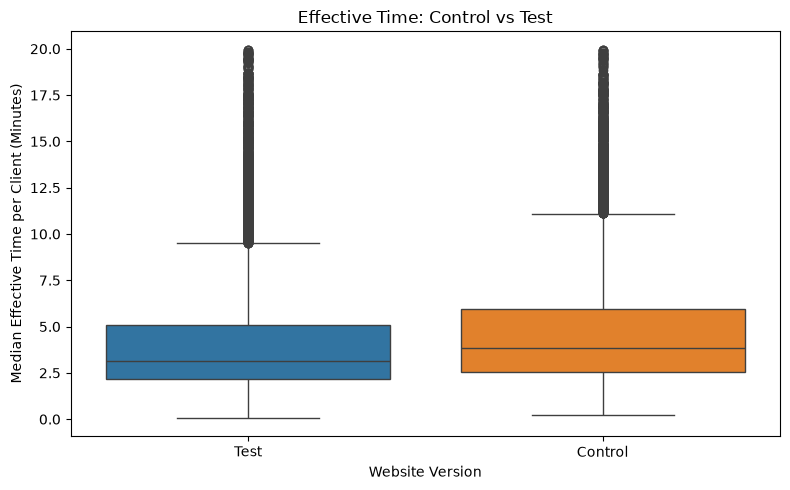

In [21]:
effective_plot_limit = client_effective_time[
    "median_effective_time"
].quantile(0.99)

effective_plot_data = client_effective_time[
    client_effective_time["median_effective_time"]
    <= effective_plot_limit
]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=effective_plot_data,
    x="Variation",
    y="median_effective_time",
    hue="Variation",
    legend=False
)

plt.title("Effective Time: Control vs Test")
plt.xlabel("Website Version")
plt.ylabel("Median Effective Time per Client (Minutes)")
plt.tight_layout()
plt.show()

### Effective-Time Box Plot Interpretation

The Test group has a lower median effective time than the Control group, confirming that the typical Test client progressed through the required stages more quickly.

The Test box is also narrower:

- Test IQR: **3.02 minutes**
- Control IQR: **3.50 minutes**

This indicates that the middle 50% of Test clients had slightly more consistent effective times.

Both distributions contain many points above the upper whiskers. These potential outliers represent clients who took substantially longer than the typical customer. The visual is restricted at the 99th percentile for readability, but these observations are retained in the statistical analysis.

Overall, the chart provides descriptive evidence that the Test experience improved effective journey speed. The Mann–Whitney U test is required to determine whether this difference is statistically supported.

### Statistical Test for Effective Time

- **Null hypothesis (\(H_0\))**: The effective-time distributions are the same for Control and Test clients.
- **Alternative hypothesis (\(H_1\))**: The effective-time distributions differ between Control and Test clients.

Because effective time is strongly right-skewed and contains outliers, the Mann–Whitney U test is used. Each client contributes one median effective time, supporting the independence assumption.

In [22]:
control_effective = client_effective_time.loc[
    client_effective_time["Variation"] == "Control",
    "median_effective_time"
]

test_effective = client_effective_time.loc[
    client_effective_time["Variation"] == "Test",
    "median_effective_time"
]

u_effective, p_effective = mannwhitneyu(
    control_effective,
    test_effective,
    alternative="two-sided"
)

effective_rank_biserial = (
    2 * u_effective
    / (len(control_effective) * len(test_effective))
) - 1

print("Mann–Whitney U statistic:", round(u_effective, 2))
print("P-value:", p_effective)
print(
    "Rank-biserial effect size:",
    round(effective_rank_biserial, 3)
)

print(
    "Median difference (Test - Control):",
    round(
        test_effective.median()
        - control_effective.median(),
        2
    ),
    "minutes"
)

Mann–Whitney U statistic: 153052825.0
P-value: 5.621585896858308e-118
Rank-biserial effect size: 0.148
Median difference (Test - Control): -0.67 minutes


### Effective-Time Statistical Result

The Mann–Whitney U test produced a p-value of approximately **5.62 × 10⁻¹¹⁸**, which is far below the significance level of 0.05.

Therefore, the null hypothesis is rejected. There is very strong statistical evidence that effective-time distributions differ between Control and Test clients, with Test clients generally recording lower effective times.

The median effective time decreased by **0.67 minutes**, equivalent to approximately **40 seconds**.

The rank-biserial effect size is **0.148**, indicating a small effect. Therefore, the improvement is highly statistically significant because of the large sample size, but its magnitude for an individual customer is modest.

From a business perspective, the redesigned website appears to make forward progression more efficient. However, this benefit must still be considered alongside the increased navigation-error and step-back rates.

In [23]:
rng = np.random.default_rng(42)

effective_bootstrap_differences = []

for _ in range(2000):
    control_sample = rng.choice(
        control_effective.to_numpy(),
        size=len(control_effective),
        replace=True
    )

    test_sample = rng.choice(
        test_effective.to_numpy(),
        size=len(test_effective),
        replace=True
    )

    effective_bootstrap_differences.append(
        np.median(test_sample)
        - np.median(control_sample)
    )

observed_effective_difference = (
    test_effective.median()
    - control_effective.median()
)

effective_ci_lower, effective_ci_upper = np.percentile(
    effective_bootstrap_differences,
    [2.5, 97.5]
)

print(
    "Observed median difference:",
    round(observed_effective_difference, 2)
)

print(
    "95% effective-time confidence interval:",
    f"[{effective_ci_lower:.2f}, {effective_ci_upper:.2f}] minutes"
)

Observed median difference: -0.67
95% effective-time confidence interval: [-0.72, -0.60] minutes


### Effective-Time Confidence Interval Result

The observed median difference in effective time was **−0.67 minutes**.

The 95% bootstrap confidence interval was:

[−0.72, −0.60] minutes

Because the entire interval is below zero, the result supports the conclusion that Test clients had lower effective times than Control clients.

The estimated reduction is between **0.60 and 0.72 minutes**, equivalent to approximately **36 to 43 seconds** per successful client.

Together with the Mann–Whitney U test, this provides strong statistical evidence that the redesigned website improved the speed of forward progression through the customer journey.

The navigation-error rate is calculated as:

#\[
\text{Error Rate}
=
\frac{\text{Navigation Errors}}
{\text{Comparable Transitions}}
\times 100
\]

In [24]:
client_errors = (
    journey_ab.groupby(["client_id", "Variation"])
    .agg(
        navigation_errors=("navigation_errors", "sum"),
        comparable_transitions=("comparable_transitions", "sum")
    )
    .reset_index()
)

# Keep clients whose error rate can be calculated
client_errors = client_errors[
    client_errors["comparable_transitions"] > 0
].copy()

client_errors["navigation_error_rate_percent"] = (
    client_errors["navigation_errors"]
    / client_errors["comparable_transitions"]
    * 100
)

client_errors["has_navigation_error"] = (
    client_errors["navigation_errors"] > 0
)

error_summary = (
    client_errors.groupby("Variation")
    .agg(
        clients=("client_id", "nunique"),
        total_errors=("navigation_errors", "sum"),
        total_transitions=("comparable_transitions", "sum"),
        clients_with_error_percent=(
            "has_navigation_error",
            lambda x: x.mean() * 100
        ),
        median_client_error_rate=(
            "navigation_error_rate_percent",
            "median"
        )
    )
)

error_summary["overall_error_rate_percent"] = (
    error_summary["total_errors"]
    / error_summary["total_transitions"]
    * 100
)

error_summary.round(2)

,clients,total_errors,total_transitions,clients_with_error_percent,median_client_error_rate,overall_error_rate_percent
Variation,,,,,,
Control,21117,23255,108293,47.16,0.00,21.47
Test,25446,35248,139495,55.35,16.67,25.27


### Navigation-Error Findings

The redesigned website produced a higher navigation-error rate than the original website.

- Overall error rate increased from **21.47% in Control to 25.27% in Test**, a difference of **3.80 percentage points**.
- Clients experiencing at least one navigation error increased from **47.16% to 55.35%**, a difference of **8.19 percentage points**.
- The median client error rate increased from **0% in Control to 16.67% in Test**.

Although the Test design improved completion and speed, these results indicate that customers were more likely to repeat stages or move backwards.

Only clients with at least one comparable transition were included. This retained **21,117 Control clients** and **25,446 Test clients**. Clients without a valid transition denominator were excluded because their error rate could not be calculated. This should be acknowledged as a limitation.

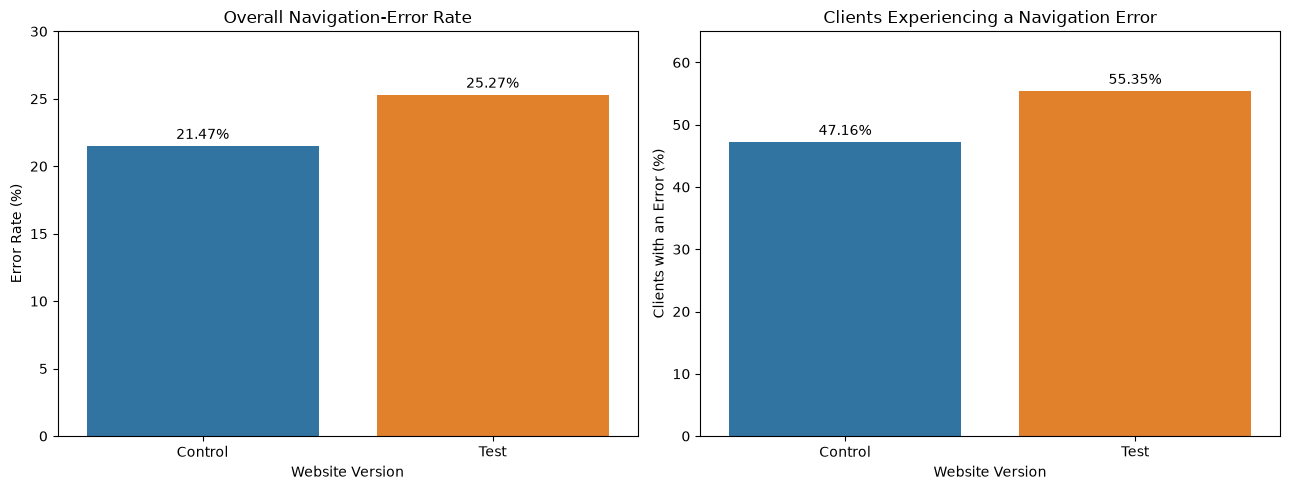

In [25]:
error_chart_data = error_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=error_chart_data,
    x="Variation",
    y="overall_error_rate_percent",
    hue="Variation",
    order=["Control", "Test"],
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Overall Navigation-Error Rate")
axes[0].set_xlabel("Website Version")
axes[0].set_ylabel("Error Rate (%)")
axes[0].set_ylim(0, 30)

sns.barplot(
    data=error_chart_data,
    x="Variation",
    y="clients_with_error_percent",
    hue="Variation",
    order=["Control", "Test"],
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Clients Experiencing a Navigation Error")
axes[1].set_xlabel("Website Version")
axes[1].set_ylabel("Clients with an Error (%)")
axes[1].set_ylim(0, 65)

# Display the exact percentage above each bar
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

### Navigation-Error Chart Interpretation

Both charts indicate that the redesigned website created more navigation friction.

The overall navigation-error rate increased from **21.47% in Control to 25.27% in Test**. This means that errors occurred more frequently relative to the number of measurable transitions.

The percentage of clients experiencing at least one navigation error also increased from **47.16% to 55.35%**. Therefore, the increase was not caused only by a small number of highly problematic journeys; navigation errors affected a broader share of Test customers.

This is an important disadvantage of the redesigned experience. Although Test customers generally progressed faster and reached confirmation more frequently, they were also more likely to repeat or reverse funnel steps.

### Statistical Test for Client Navigation-Error Rate

- **Null hypothesis (\(H_0\))**: Client navigation-error-rate distributions are the same in the Control and Test groups.
- **Alternative hypothesis (\(H_1\))**: Client navigation-error-rate distributions differ between the groups.

Client error rates are bounded at zero, contain many zero values and are not normally distributed. Therefore, the Mann–Whitney U test is used.

Each client contributes one error rate, supporting the independence assumption.

In [26]:
control_error_rate = client_errors.loc[
    client_errors["Variation"] == "Control",
    "navigation_error_rate_percent"
]

test_error_rate = client_errors.loc[
    client_errors["Variation"] == "Test",
    "navigation_error_rate_percent"
]

u_error, p_error = mannwhitneyu(
    control_error_rate,
    test_error_rate,
    alternative="two-sided"
)

error_rank_biserial = (
    2 * u_error
    / (len(control_error_rate) * len(test_error_rate))
) - 1

print("Control clients:", len(control_error_rate))
print("Test clients:", len(test_error_rate))
print("Mann–Whitney U statistic:", round(u_error, 2))
print("P-value:", p_error)
print(
    "Rank-biserial effect size:",
    round(error_rank_biserial, 3)
)

Control clients: 21117
Test clients: 25446
Mann–Whitney U statistic: 242492515.0
P-value: 1.0705018686861338e-82
Rank-biserial effect size: -0.097


### Navigation-Error-Rate Statistical Result

The Mann–Whitney U test produced a p-value of approximately **1.07 × 10⁻⁸²**, which is far below 0.05.

Therefore, the null hypothesis is rejected. There is very strong statistical evidence that client navigation-error rates differ between Control and Test.

The rank-biserial effect size is **−0.097**. The negative sign indicates that Control error rates generally rank lower than Test error rates because Control was entered first in the test. The absolute effect size is small.

Although the individual-level effect is small, the difference may still be practically important because the redesigned website increased the overall error rate from **21.47% to 25.27%** and affected a larger share of customers.

### Clients Experiencing at Least One Error

A two-proportion z-test evaluates whether the percentage of clients experiencing at least one navigation error differs between the Control and Test groups.

- **Null hypothesis (\(H_0\))**: The proportion of clients experiencing a navigation error is equal in Control and Test.
- **Alternative hypothesis (\(H_1\))**: The proportions differ between Control and Test.

The large sample sizes and sufficient numbers of both error and no-error outcomes satisfy the normal-approximation assumption.

In [27]:
from scipy.stats import norm

control_error_clients = int(
    client_errors.loc[
        client_errors["Variation"] == "Control",
        "has_navigation_error"
    ].sum()
)

test_error_clients = int(
    client_errors.loc[
        client_errors["Variation"] == "Test",
        "has_navigation_error"
    ].sum()
)

n_control_error = (
    client_errors["Variation"] == "Control"
).sum()

n_test_error = (
    client_errors["Variation"] == "Test"
).sum()

p_control_error = (
    control_error_clients / n_control_error
)

p_test_error = (
    test_error_clients / n_test_error
)

# Pooled proportion used for the hypothesis test
pooled_error = (
    control_error_clients + test_error_clients
) / (
    n_control_error + n_test_error
)

standard_error_null = np.sqrt(
    pooled_error
    * (1 - pooled_error)
    * (
        1 / n_control_error
        + 1 / n_test_error
    )
)

z_error = (
    p_test_error - p_control_error
) / standard_error_null

p_error_proportion = (
    2 * norm.sf(abs(z_error))
)

# Difference and 95% confidence interval: Test - Control
error_difference = (
    p_test_error - p_control_error
)

standard_error_difference = np.sqrt(
    p_test_error * (1 - p_test_error) / n_test_error
    + p_control_error * (1 - p_control_error) / n_control_error
)

error_ci_lower = (
    error_difference
    - 1.96 * standard_error_difference
)

error_ci_upper = (
    error_difference
    + 1.96 * standard_error_difference
)

print("Control proportion:", f"{p_control_error:.2%}")
print("Test proportion:", f"{p_test_error:.2%}")
print("Difference:", f"{error_difference:.2%}")
print("Z statistic:", round(z_error, 4))
print("P-value:", p_error_proportion)

print(
    "95% confidence interval:",
    f"[{error_ci_lower:.2%}, {error_ci_upper:.2%}]"
)

Control proportion: 47.16%
Test proportion: 55.35%
Difference: 8.19%
Z statistic: 17.6088
P-value: 2.1090039869385835e-69
95% confidence interval: [7.28%, 9.10%]


### Clients Experiencing an Error: Statistical Result

The percentage of clients experiencing at least one navigation error increased from **47.16% in Control to 55.35% in Test**.

This represents an increase of **8.19 percentage points**.

The two-proportion z-test produced:

- \(z = 17.6088\)
- \(p \approx 2.11 \times 10^{-69}\)

Because the p-value is far below 0.05, the null hypothesis is rejected. There is very strong statistical evidence that Test clients were more likely to experience a navigation error.

The 95% confidence interval for the increase is:

\[
[7.28\%,\ 9.10\%]
\]

Because the entire interval is above zero, the increase is statistically supported. From a practical perspective, approximately **7 to 9 additional clients out of every 100** experienced a navigation error under the redesigned website.

This is a meaningful disadvantage and should be weighed against the Test group’s higher completion rate and faster completion times.

### Visual Distribution of Client Navigation-Error Rates

The histogram shows how client error rates are distributed across each experimental group. The box plot summarises the median and interquartile range.

The visual is limited to the 99th percentile so that extreme observations do not compress the main distribution. No observations are removed from the statistical analysis.

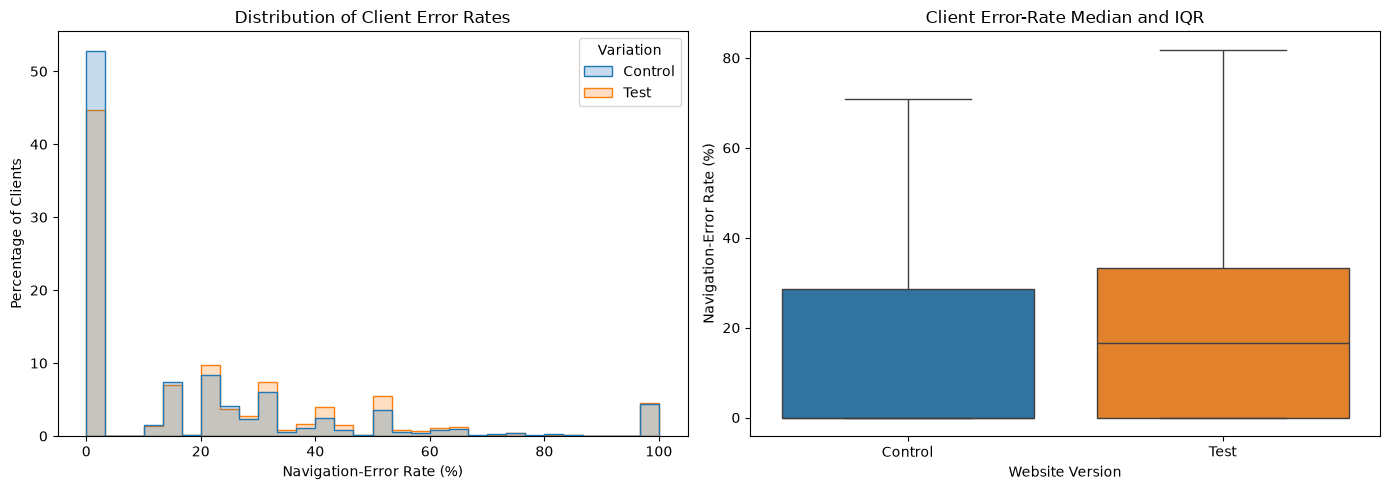

In [28]:
# Consistent colours throughout the notebook
group_colors = {
    "Control": "#1f77b4",
    "Test": "#ff7f0e"
}

# Restrict only the visual to the 99th percentile
error_plot_limit = client_errors[
    "navigation_error_rate_percent"
].quantile(0.99)

error_plot_data = client_errors[
    client_errors["navigation_error_rate_percent"]
    <= error_plot_limit
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: distribution of client error rates
sns.histplot(
    data=error_plot_data,
    x="navigation_error_rate_percent",
    hue="Variation",
    hue_order=["Control", "Test"],
    palette=group_colors,
    bins=30,
    stat="percent",
    common_norm=False,
    element="step",
    ax=axes[0]
)

axes[0].set_title("Distribution of Client Error Rates")
axes[0].set_xlabel("Navigation-Error Rate (%)")
axes[0].set_ylabel("Percentage of Clients")

# Box plot: median and IQR
sns.boxplot(
    data=error_plot_data,
    x="Variation",
    y="navigation_error_rate_percent",
    hue="Variation",
    order=["Control", "Test"],
    hue_order=["Control", "Test"],
    palette=group_colors,
    legend=False,
    showfliers=False,
    ax=axes[1]
)

axes[1].set_title("Client Error-Rate Median and IQR")
axes[1].set_xlabel("Website Version")
axes[1].set_ylabel("Navigation-Error Rate (%)")

plt.tight_layout()
plt.show()

### Navigation-Error Distribution Interpretation

The histogram shows that many clients in both groups had an error rate of zero. However, the concentration at zero is higher for Control, indicating that a larger proportion of Control clients completed their measurable transitions without navigation errors.

The Test distribution contains a greater concentration of clients at positive error rates. This indicates that navigation friction was more common under the redesigned website.

The box plot supports this finding:

- The Control median navigation-error rate is **0%**.
- The Test median navigation-error rate is **16.67%**.
- The Test group has a higher upper quartile, showing that error rates were also higher across the middle range of Test clients.

The distributions contain many zero values and are not normally distributed. This supports the use of the Mann–Whitney U test rather than an independent-samples t-test.

Together, the descriptive statistics, visualisations and statistical tests show that the redesigned website increased navigation errors. This is a meaningful disadvantage that should be weighed against its higher completion rate and faster completion times.

## Step-Back Analysis

A step back occurs when a customer moves from a later funnel stage to an earlier stage, such as moving from `step_3` back to `step_2`.

Step backs indicate possible confusion, correction or difficulty completing the process.

The step-back transition rate is calculated as:

$$
\text{Step-Back Rate}
=
\frac{\text{Total Step Backs}}
{\text{Comparable Transitions}}
\times 100
$$

A lower step-back rate represents a smoother and more direct customer journey.

In [29]:
client_stepbacks = (
    journey_ab.groupby(["client_id", "Variation"])
    .agg(
        step_backs=("step_backs", "sum"),
        comparable_transitions=("comparable_transitions", "sum"),
        journeys=("visit_id", "count")
    )
    .reset_index()
)

client_stepbacks["has_step_back"] = (
    client_stepbacks["step_backs"] > 0
)

client_stepbacks["average_step_backs_per_journey"] = (
    client_stepbacks["step_backs"]
    / client_stepbacks["journeys"]
)

client_stepbacks["step_back_rate_percent"] = np.where(
    client_stepbacks["comparable_transitions"] > 0,
    client_stepbacks["step_backs"]
    / client_stepbacks["comparable_transitions"]
    * 100,
    np.nan
)

step_back_summary = (
    client_stepbacks.groupby("Variation")
    .agg(
        clients=("client_id", "nunique"),
        total_step_backs=("step_backs", "sum"),
        total_transitions=("comparable_transitions", "sum"),
        clients_with_step_back_percent=(
            "has_step_back",
            lambda x: x.mean() * 100
        ),
        average_step_backs_per_client=(
            "step_backs",
            "mean"
        ),
        median_step_backs_per_client=(
            "step_backs",
            "median"
        )
    )
)

step_back_summary["overall_step_back_rate_percent"] = (
    step_back_summary["total_step_backs"]
    / step_back_summary["total_transitions"]
    * 100
)

step_back_summary.round(2)

,clients,total_step_backs,total_transitions,clients_with_step_back_percent,average_step_backs_per_client,median_step_backs_per_client,overall_step_back_rate_percent
Variation,,,,,,,
Control,23532,9581,108293,26.10,0.41,0.0,8.85
Test,26968,16232,139495,33.41,0.60,0.0,11.64


### Step-Back Findings

The Test group experienced more step backs under every descriptive measure.

- The overall step-back rate increased from **8.85% in Control to 11.64% in Test**, a difference of **2.79 percentage points**.
- Clients experiencing at least one step back increased from **26.10% to 33.41%**, a difference of **7.31 percentage points**.
- Average step backs per client increased from **0.41 to 0.60**.

The median is zero for both groups because more than half of the clients did not experience a step back. However, step backs affected a noticeably larger proportion of Test clients.

This suggests that although the redesigned website helped customers progress faster overall, it also caused more customers to return to earlier stages.

In [30]:
valid_stepback_rates = client_stepbacks[
    client_stepbacks["step_back_rate_percent"].notna()
].copy()

stepback_descriptive = (
    valid_stepback_rates.groupby("Variation")[
        "step_back_rate_percent"
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .round(2)
)

print("Step-back-rate skewness:")

print(
    valid_stepback_rates.groupby("Variation")[
        "step_back_rate_percent"
    ].skew().round(2)
)

stepback_descriptive

Step-back-rate skewness:
Variation
Control    1.92
Test       1.54
Name: step_back_rate_percent, dtype: float64


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
Variation,,,,,,,,,,,
Control,21117.0,6.13,10.95,0.0,0.0,0.0,12.50,22.22,28.57,50.0,100.0
Test,25446.0,8.29,13.05,0.0,0.0,0.0,16.67,27.27,33.33,50.0,100.0


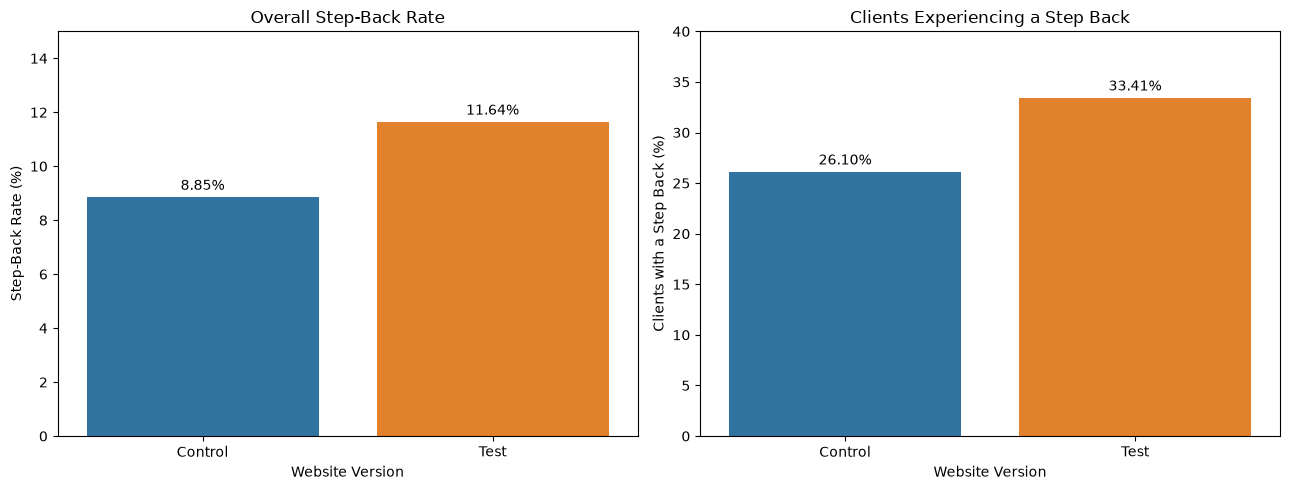

In [31]:
stepback_chart_data = step_back_summary.reset_index()

group_colors = {
    "Control": "#1f77b4",
    "Test": "#ff7f0e"
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=stepback_chart_data,
    x="Variation",
    y="overall_step_back_rate_percent",
    hue="Variation",
    order=["Control", "Test"],
    hue_order=["Control", "Test"],
    palette=group_colors,
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Overall Step-Back Rate")
axes[0].set_xlabel("Website Version")
axes[0].set_ylabel("Step-Back Rate (%)")
axes[0].set_ylim(0, 15)

sns.barplot(
    data=stepback_chart_data,
    x="Variation",
    y="clients_with_step_back_percent",
    hue="Variation",
    order=["Control", "Test"],
    hue_order=["Control", "Test"],
    palette=group_colors,
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Clients Experiencing a Step Back")
axes[1].set_xlabel("Website Version")
axes[1].set_ylabel("Clients with a Step Back (%)")
axes[1].set_ylim(0, 40)

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

### Step-Back Chart Interpretation

Both step-back measures are higher for the redesigned website.

The overall step-back rate increased from **8.85% in Control to 11.64% in Test**, meaning backward movements occurred more frequently relative to measurable transitions.

The percentage of clients experiencing at least one step back increased from **26.10% to 33.41%**. This means approximately **7 additional clients out of every 100** experienced backward navigation under the redesigned website.

The increase is therefore visible both in the frequency of backward movements and in the proportion of customers affected.

This provides descriptive evidence that the Test design created more navigation friction, even though it improved completion speed and overall funnel progression.

In [32]:
stepback_descriptive

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
Variation,,,,,,,,,,,
Control,21117.0,6.13,10.95,0.0,0.0,0.0,12.50,22.22,28.57,50.0,100.0
Test,25446.0,8.29,13.05,0.0,0.0,0.0,16.67,27.27,33.33,50.0,100.0


### Step-Back Descriptive Statistics

The median step-back rate is **0% for both groups** because more than half of the clients did not experience a step back.

However, differences become visible higher in the distributions:

- The 75th percentile is **12.50% for Control** and **16.67% for Test**.
- The 90th percentile is **22.22% for Control** and **27.27% for Test**.
- The 95th percentile is **28.57% for Control** and **33.33% for Test**.
- The mean client step-back rate is **6.13% for Control** and **8.29% for Test**.

The IQR is **12.50 percentage points for Control** and **16.67 percentage points for Test**, showing greater variation in step-back rates among Test clients.

The many zero values and long upper tails indicate strongly non-normal distributions. Therefore, the Mann–Whitney U test is more appropriate than an independent-samples t-test.

### Statistical Test for Client Step-Back Rate

- **Null hypothesis (\(H_0\))**: Client step-back-rate distributions are the same in Control and Test.
- **Alternative hypothesis (\(H_1\))**: Client step-back-rate distributions differ between Control and Test.

The Mann–Whitney U test is used because the distributions contain many zeros, are right-skewed and are not normally distributed.

In [33]:
control_stepback_rate = valid_stepback_rates.loc[
    valid_stepback_rates["Variation"] == "Control",
    "step_back_rate_percent"
]

test_stepback_rate = valid_stepback_rates.loc[
    valid_stepback_rates["Variation"] == "Test",
    "step_back_rate_percent"
]

u_stepback, p_stepback = mannwhitneyu(
    control_stepback_rate,
    test_stepback_rate,
    alternative="two-sided"
)

stepback_rank_biserial = (
    2 * u_stepback
    / (
        len(control_stepback_rate)
        * len(test_stepback_rate)
    )
) - 1

print("Control clients:", len(control_stepback_rate))
print("Test clients:", len(test_stepback_rate))
print("Mann–Whitney U statistic:", round(u_stepback, 2))
print("P-value:", p_stepback)
print(
    "Rank-biserial effect size:",
    round(stepback_rank_biserial, 3)
)

Control clients: 21117
Test clients: 25446
Mann–Whitney U statistic: 248658925.0
P-value: 2.871378899924254e-62
Rank-biserial effect size: -0.074


### Step-Back-Rate Statistical Result

The Mann–Whitney U test produced a p-value of approximately **2.87 × 10⁻⁶²**, which is far below 0.05.

Therefore, the null hypothesis is rejected. There is very strong statistical evidence that client step-back-rate distributions differ between Control and Test.

The rank-biserial effect size is **−0.074**. The negative sign indicates that Control step-back rates generally rank lower than Test rates. However, the absolute effect size is very small.

This demonstrates why statistical and practical significance must be considered separately. The large sample provides strong evidence that a difference exists, but the individual-level difference is relatively small. Nevertheless, the increase affects many customers and indicates additional friction in the redesigned journey.

### Clients Experiencing at Least One Step Back

A two-proportion z-test evaluates whether the percentage of clients experiencing at least one step back differs between Control and Test.

- **Null hypothesis (\(H_0\))**: The proportion is equal in both groups.
- **Alternative hypothesis (\(H_1\))**: The proportions differ between the groups.

In [34]:
control_stepback_clients = int(
    client_stepbacks.loc[
        client_stepbacks["Variation"] == "Control",
        "has_step_back"
    ].sum()
)

test_stepback_clients = int(
    client_stepbacks.loc[
        client_stepbacks["Variation"] == "Test",
        "has_step_back"
    ].sum()
)

n_control_stepback = (
    client_stepbacks["Variation"] == "Control"
).sum()

n_test_stepback = (
    client_stepbacks["Variation"] == "Test"
).sum()

p_control_stepback = (
    control_stepback_clients / n_control_stepback
)

p_test_stepback = (
    test_stepback_clients / n_test_stepback
)

pooled_stepback = (
    control_stepback_clients + test_stepback_clients
) / (
    n_control_stepback + n_test_stepback
)

stepback_standard_error_null = np.sqrt(
    pooled_stepback
    * (1 - pooled_stepback)
    * (
        1 / n_control_stepback
        + 1 / n_test_stepback
    )
)

z_stepback = (
    p_test_stepback - p_control_stepback
) / stepback_standard_error_null

p_stepback_proportion = (
    2 * norm.sf(abs(z_stepback))
)

stepback_difference = (
    p_test_stepback - p_control_stepback
)

stepback_standard_error_difference = np.sqrt(
    p_test_stepback * (1 - p_test_stepback) / n_test_stepback
    + p_control_stepback * (1 - p_control_stepback) / n_control_stepback
)

stepback_ci_lower = (
    stepback_difference
    - 1.96 * stepback_standard_error_difference
)

stepback_ci_upper = (
    stepback_difference
    + 1.96 * stepback_standard_error_difference
)

print("Control proportion:", f"{p_control_stepback:.2%}")
print("Test proportion:", f"{p_test_stepback:.2%}")
print("Difference:", f"{stepback_difference:.2%}")
print("Z statistic:", round(z_stepback, 4))
print("P-value:", p_stepback_proportion)

print(
    "95% confidence interval:",
    f"[{stepback_ci_lower:.2%}, "
    f"{stepback_ci_upper:.2%}]"
)

Control proportion: 26.10%
Test proportion: 33.41%
Difference: 7.31%
Z statistic: 17.8884
P-value: 1.4514055547352555e-71
95% confidence interval: [6.52%, 8.11%]


### Clients Experiencing a Step Back: Statistical Result

The percentage of clients experiencing at least one step back increased from **26.10% in Control to 33.41% in Test**.

This represents an increase of **7.31 percentage points**.

The two-proportion z-test produced:

- \(z = 17.8884\)
- \(p \approx 1.45 \times 10^{-71}\)

Because the p-value is far below 0.05, the null hypothesis is rejected. There is very strong statistical evidence that Test clients were more likely to experience backward navigation.

The 95% confidence interval for the increase is:

\[
[6.52\%,\ 8.11\%]
\]

The interval suggests that the redesigned website caused approximately **6.5 to 8.1 additional clients out of every 100** to experience a step back.

Although the rank-based effect size was very small, the increase affects a meaningful proportion of customers. This strengthens the evidence that the redesigned website introduced additional navigation friction.

## Client-Level Completion Rate

A client is classified as completed if at least one of their recorded journeys reached the `confirm` stage.

The client-level completion rate is:

$$
\text{Completion Rate}
=
\frac{\text{Clients Reaching Confirm}}
{\text{Total Experiment Clients}}
\times 100
$$

Client-level measurement is appropriate for the A/B test because experimental assignment occurs at the client level. Each client is counted once, even if they made several visits.

In [35]:
client_completion = (
    journey_ab.groupby(["client_id", "Variation"])
    .agg(
        completed=("completed", "max")
    )
    .reset_index()
)

completion_summary = (
    client_completion.groupby("Variation")
    .agg(
        total_clients=("client_id", "nunique"),
        completed_clients=("completed", "sum"),
        completion_rate=("completed", "mean")
    )
)

completion_summary["completion_rate_percent"] = (
    completion_summary["completion_rate"] * 100
)

completion_summary.round(2)

,total_clients,completed_clients,completion_rate,completion_rate_percent
Variation,,,,
Control,23532,15434,0.66,65.59
Test,26968,18687,0.69,69.29


### Completion-Definition Validation

Several completion-related fields were compared before calculating the primary KPI.

The `completed` field and `number_of_confirms > 0` produced identical results and match the project definition: a client is completed if any recorded journey contains a `confirm` event.

The `reached_confirm` and `valid_completion` fields apply additional journey conditions and therefore produce lower rates. They are useful for funnel-quality analysis but are not used for the primary client-level completion KPI.

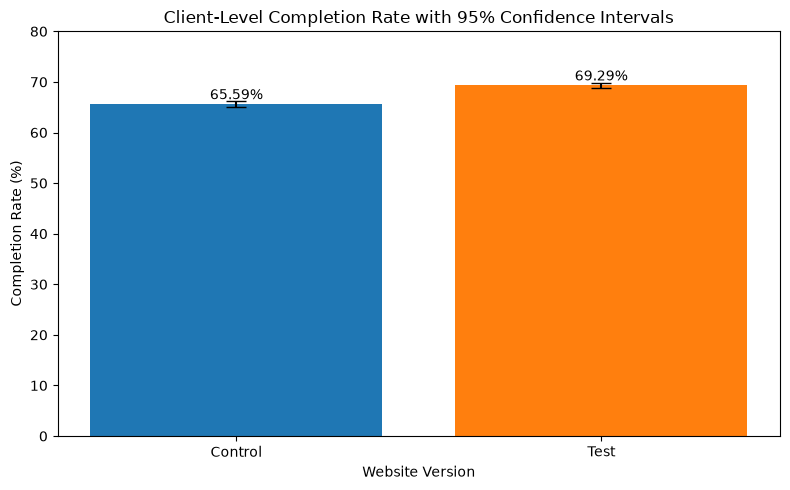

In [36]:
completion_chart_data = completion_summary.reset_index()

completion_chart_data["standard_error"] = np.sqrt(
    completion_chart_data["completion_rate"]
    * (1 - completion_chart_data["completion_rate"])
    / completion_chart_data["total_clients"]
)

completion_chart_data["ci_95"] = (
    1.96
    * completion_chart_data["standard_error"]
    * 100
)

completion_chart_data = (
    completion_chart_data
    .set_index("Variation")
    .loc[["Control", "Test"]]
    .reset_index()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    completion_chart_data["Variation"],
    completion_chart_data["completion_rate_percent"],
    yerr=completion_chart_data["ci_95"],
    capsize=7,
    color=[
        group_colors["Control"],
        group_colors["Test"]
    ]
)

plt.title(
    "Client-Level Completion Rate with 95% Confidence Intervals"
)
plt.xlabel("Website Version")
plt.ylabel("Completion Rate (%)")
plt.ylim(0, 80)

for bar, value in zip(
    bars,
    completion_chart_data["completion_rate_percent"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Completion-Rate Chart Interpretation

The Test group achieved a client-level completion rate of **69.29%**, compared with **65.59% for Control**.

This represents:

- An absolute improvement of **3.70 percentage points**.
- A relative improvement of approximately **5.64%** compared with the Control completion rate.
- Approximately **3.7 additional completed clients for every 100 customers** using the redesigned website.

The 95% confidence-interval bars are narrow because both experimental groups contain large numbers of clients. A two-proportion z-test will determine whether the observed difference is statistically supported.

### Statistical Test for Client Completion Rate

- **Null hypothesis (\(H_0\))**: The client completion rate is equal in Control and Test.
- **Alternative hypothesis (\(H_1\))**: The client completion rates differ.

A two-proportion z-test is appropriate because completion is binary, the groups are independent and both groups contain sufficiently large numbers of completed and non-completed clients.

In [37]:
control_completed = int(
    completion_summary.loc["Control", "completed_clients"]
)

test_completed = int(
    completion_summary.loc["Test", "completed_clients"]
)

n_control_completion = int(
    completion_summary.loc["Control", "total_clients"]
)

n_test_completion = int(
    completion_summary.loc["Test", "total_clients"]
)

p_control_completion = (
    control_completed / n_control_completion
)

p_test_completion = (
    test_completed / n_test_completion
)

pooled_completion = (
    control_completed + test_completed
) / (
    n_control_completion + n_test_completion
)

completion_standard_error_null = np.sqrt(
    pooled_completion
    * (1 - pooled_completion)
    * (
        1 / n_control_completion
        + 1 / n_test_completion
    )
)

z_completion = (
    p_test_completion - p_control_completion
) / completion_standard_error_null

p_completion = (
    2 * norm.sf(abs(z_completion))
)

completion_difference = (
    p_test_completion - p_control_completion
)

completion_standard_error_difference = np.sqrt(
    p_test_completion
    * (1 - p_test_completion)
    / n_test_completion
    + p_control_completion
    * (1 - p_control_completion)
    / n_control_completion
)

completion_ci_lower = (
    completion_difference
    - 1.96 * completion_standard_error_difference
)

completion_ci_upper = (
    completion_difference
    + 1.96 * completion_standard_error_difference
)

print("Control completion rate:", f"{p_control_completion:.2%}")
print("Test completion rate:", f"{p_test_completion:.2%}")
print("Difference:", f"{completion_difference:.2%}")
print("Z statistic:", round(z_completion, 4))
print("P-value:", p_completion)

print(
    "95% confidence interval:",
    f"[{completion_ci_lower:.2%}, "
    f"{completion_ci_upper:.2%}]"
)

Control completion rate: 65.59%
Test completion rate: 69.29%
Difference: 3.71%
Z statistic: 8.8745
P-value: 7.023933247581432e-19
95% confidence interval: [2.89%, 4.53%]


### Client Completion-Rate Statistical Result

The client completion rate increased from **65.59% in Control to 69.29% in Test**, an absolute improvement of **3.71 percentage points**.

The two-proportion z-test produced:

- \(z = 8.8745\)
- \(p \approx 7.02 \times 10^{-19}\)

Because the p-value is far below 0.05, the null hypothesis is rejected. There is very strong statistical evidence that the redesigned website increased the client completion rate.

The 95% confidence interval for the improvement is:

\[
[2.89\%,\ 4.53\%]
\]

This suggests that the redesigned website would produce approximately **2.9 to 4.5 additional completed clients for every 100 customers**.

The improvement is statistically significant and potentially meaningful at business scale. However, it should be evaluated alongside the statistically supported increases in navigation errors and step backs.

## Statistical Evidence for Funnel Progression

Funnel progression is tested at the client level to maintain independence. Each client is counted once and is classified according to whether any journey with a recorded start reached each subsequent stage.

For every funnel stage:

- **Null hypothesis (\(H_0\))**: The proportion of clients reaching the stage is equal in Control and Test.
- **Alternative hypothesis (\(H_1\))**: The proportions differ between Control and Test.

Two-proportion z-tests are used because stage reach is binary and the sample sizes are large.

Four related stage comparisons are performed. Therefore, Bonferroni-adjusted p-values are reported to reduce the risk of false-positive findings from multiple testing.

In [38]:
client_funnel = (
    started_journeys.groupby(["client_id", "Variation"])
    .agg(
        reached_step_1=("reached_step_1", "max"),
        reached_step_2=("reached_step_2", "max"),
        reached_step_3=("reached_step_3", "max"),
        reached_confirm=("reached_confirm", "max")
    )
    .reset_index()
)

funnel_test_columns = [
    "reached_step_1",
    "reached_step_2",
    "reached_step_3",
    "reached_confirm"
]

funnel_test_labels = {
    "reached_step_1": "Reached Step 1",
    "reached_step_2": "Reached Step 2",
    "reached_step_3": "Reached Step 3",
    "reached_confirm": "Reached Confirm"
}

funnel_test_results = []

for column in funnel_test_columns:
    control_values = client_funnel.loc[
        client_funnel["Variation"] == "Control",
        column
    ]

    test_values = client_funnel.loc[
        client_funnel["Variation"] == "Test",
        column
    ]

    control_successes = int(control_values.sum())
    test_successes = int(test_values.sum())

    n_control = len(control_values)
    n_test = len(test_values)

    control_rate = control_successes / n_control
    test_rate = test_successes / n_test

    difference = test_rate - control_rate

    pooled_rate = (
        control_successes + test_successes
    ) / (
        n_control + n_test
    )

    null_se = np.sqrt(
        pooled_rate
        * (1 - pooled_rate)
        * (
            1 / n_control
            + 1 / n_test
        )
    )

    z_statistic = difference / null_se
    p_value = 2 * norm.sf(abs(z_statistic))

    difference_se = np.sqrt(
        control_rate * (1 - control_rate) / n_control
        + test_rate * (1 - test_rate) / n_test
    )

    ci_lower = difference - 1.96 * difference_se
    ci_upper = difference + 1.96 * difference_se

    funnel_test_results.append({
        "stage": funnel_test_labels[column],
        "Control_rate_percent": control_rate * 100,
        "Test_rate_percent": test_rate * 100,
        "difference_pp": difference * 100,
        "z_statistic": z_statistic,
        "p_value": p_value,
        "ci_lower_pp": ci_lower * 100,
        "ci_upper_pp": ci_upper * 100
    })

funnel_statistical_results = pd.DataFrame(
    funnel_test_results
)

# Bonferroni adjustment for four stage comparisons
funnel_statistical_results["adjusted_p_value"] = np.minimum(
    funnel_statistical_results["p_value"] * 4,
    1
)

funnel_statistical_results.round(4)

,stage,Control_rate_percent,Test_rate_percent,difference_pp,z_statistic,p_value,ci_lower_pp,ci_upper_pp,adjusted_p_value
0,Reached Step 1,85.4725,90.3782,4.9057,16.9072,0.0,4.3320,5.4794,0.0
1,Reached Step 2,78.5528,82.2557,3.7029,10.4398,0.0,3.0052,4.4006,0.0
2,Reached Step 3,72.4965,76.2023,3.7058,9.4890,0.0,2.9386,4.4729,0.0
3,Reached Confirm,63.2731,66.9215,3.6485,8.5526,0.0,2.8116,4.4853,0.0


### Funnel-Progression Statistical Findings

The Test group had a statistically higher client reach rate at every funnel stage.

- Step 1: **+4.91 percentage points**
- Step 2: **+3.70 percentage points**
- Step 3: **+3.71 percentage points**
- Confirm: **+3.65 percentage points**

All 95% confidence intervals are entirely above zero, and all differences remain statistically significant after the Bonferroni adjustment.

The largest improvement occurs at Step 1, supporting the earlier exploratory finding that the redesigned website was particularly effective at encouraging customers to move beyond the beginning of the process.

The Test advantage becomes smaller after Step 1 but remains positive through confirmation. This indicates that the redesigned website improved overall client progression, although it did not eliminate later-stage friction.

In [39]:
funnel_statistical_results[
    ["stage", "p_value", "adjusted_p_value"]
].style.format({
    "p_value": "{:.3e}",
    "adjusted_p_value": "{:.3e}"
})

,stage,p_value,adjusted_p_value
0,Reached Step 1,3.984e-64,1.594e-63
1,Reached Step 2,1.631e-25,6.525e-25
2,Reached Step 3,2.334e-21,9.334e-21
3,Reached Confirm,1.204e-17,4.814e-17


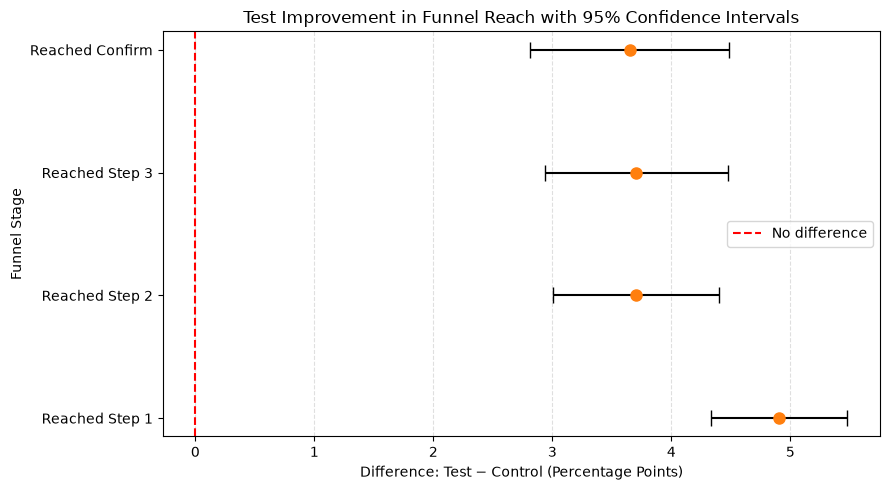

In [40]:
funnel_ci_plot = funnel_statistical_results.copy()

lower_errors = (
    funnel_ci_plot["difference_pp"]
    - funnel_ci_plot["ci_lower_pp"]
)

upper_errors = (
    funnel_ci_plot["ci_upper_pp"]
    - funnel_ci_plot["difference_pp"]
)

plt.figure(figsize=(9, 5))

plt.errorbar(
    funnel_ci_plot["difference_pp"],
    funnel_ci_plot["stage"],
    xerr=[lower_errors, upper_errors],
    fmt="o",
    color=group_colors["Test"],
    ecolor="black",
    capsize=6,
    markersize=8
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    label="No difference"
)

plt.title(
    "Test Improvement in Funnel Reach with 95% Confidence Intervals"
)
plt.xlabel("Difference: Test − Control (Percentage Points)")
plt.ylabel("Funnel Stage")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

### Funnel Confidence-Interval Interpretation

All four adjusted p-values are far below 0.05, providing strong statistical evidence that Test clients were more likely to reach each funnel stage.

The confidence-interval chart shows that:

- Every estimated difference is positive.
- Every 95% confidence interval lies entirely above the red zero line.
- The largest improvement occurs at Step 1.
- The Test advantage remains approximately 3.6–3.7 percentage points through the later stages.

The Step 1 improvement is estimated at approximately **4.33 to 5.48 percentage points**. By the confirmation stage, the estimated improvement is approximately **2.81 to 4.49 percentage points**.

This supports the conclusion that the redesigned website improved overall funnel progression. However, the statistical significance of these improvements does not remove the business concern that Test clients also experienced more navigation errors and step backs.

In [41]:
practical_significance = pd.DataFrame({
    "KPI": [
        "Client Completion Rate",
        "Median Completion Time",
        "Median Effective Time",
        "Clients with Navigation Error",
        "Clients with Step Back",
        "Clients Reaching Confirm"
    ],
    "Control": [
        "65.59%",
        "4.08 min",
        "3.87 min",
        "47.16%",
        "26.10%",
        "63.27%"
    ],
    "Test": [
        "69.29%",
        "3.32 min",
        "3.20 min",
        "55.35%",
        "33.41%",
        "66.92%"
    ],
    "Test_minus_Control": [
        "+3.71 pp",
        "-0.77 min",
        "-0.67 min",
        "+8.19 pp",
        "+7.31 pp",
        "+3.65 pp"
    ],
    "Business_direction": [
        "Favourable",
        "Favourable",
        "Favourable",
        "Unfavourable",
        "Unfavourable",
        "Favourable"
    ],
    "Statistical_evidence": [
        "Significant",
        "Significant",
        "Significant",
        "Significant",
        "Significant",
        "Significant"
    ]
})

practical_significance

,KPI,Control,Test,Test_minus_Control,Business_direction,Statistical_evidence
0,Client Completion Rate,65.59%,69.29%,+3.71 pp,Favourable,Significant
1,Median Completion Time,4.08 min,3.32 min,-0.77 min,Favourable,Significant
2,Median Effective Time,3.87 min,3.20 min,-0.67 min,Favourable,Significant
3,Clients with Navigation Error,47.16%,55.35%,+8.19 pp,Unfavourable,Significant
4,Clients with Step Back,26.10%,33.41%,+7.31 pp,Unfavourable,Significant
5,Clients Reaching Confirm,63.27%,66.92%,+3.65 pp,Favourable,Significant


## Practical-Significance Summary

All major KPI differences are statistically significant. However, their business meanings differ.

The redesigned website produced favourable improvements in:

- Client completion rate.
- Funnel confirmation.
- Completion time.
- Effective time.

It also produced unfavourable increases in:

- Clients experiencing navigation errors.
- Clients experiencing step backs.

The statistical evidence therefore does not support an unconditional conclusion that the Test design is better. The recommendation must balance improved conversion and speed against increased customer friction.

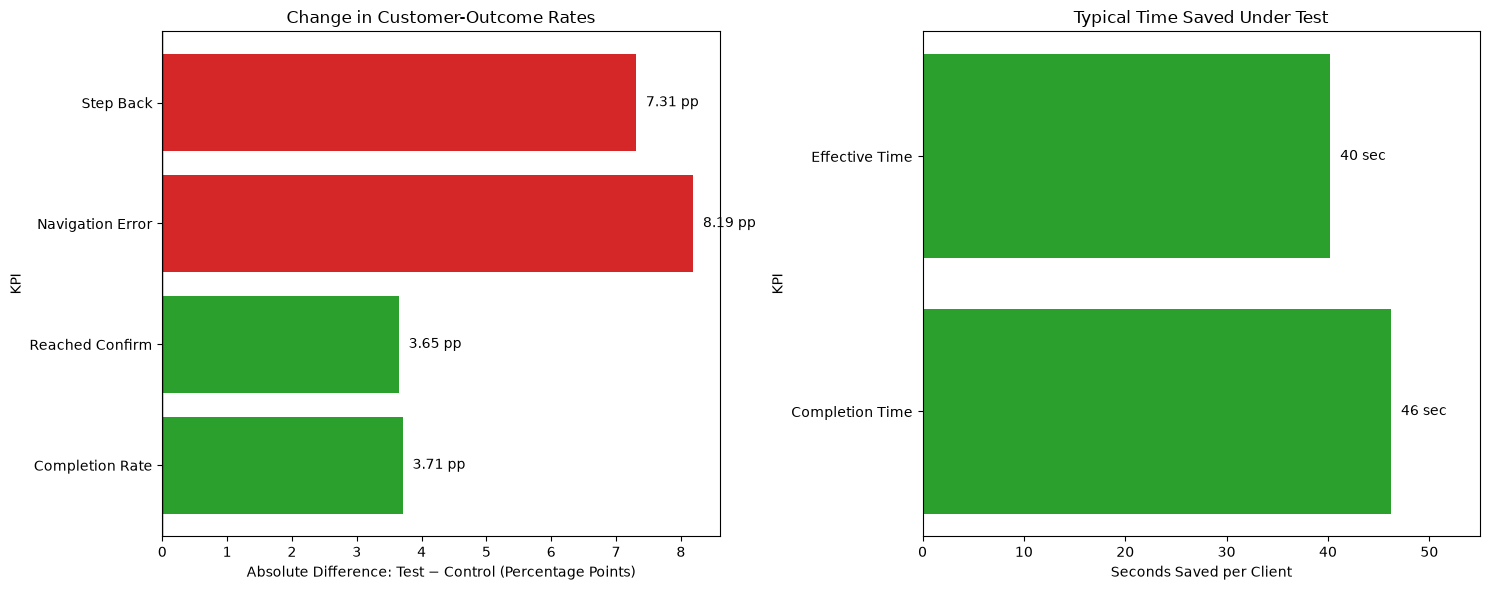

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Percentage-point KPI changes
rate_effects = pd.DataFrame({
    "KPI": [
        "Completion Rate",
        "Reached Confirm",
        "Navigation Error",
        "Step Back"
    ],
    "difference_pp": [
        3.71,
        3.65,
        8.19,
        7.31
    ],
    "direction": [
        "Favourable",
        "Favourable",
        "Unfavourable",
        "Unfavourable"
    ]
})

business_colors = {
    "Favourable": "#2ca02c",
    "Unfavourable": "#d62728"
}

rate_colors = rate_effects[
    "direction"
].map(business_colors)

bars_1 = axes[0].barh(
    rate_effects["KPI"],
    rate_effects["difference_pp"],
    color=rate_colors
)

axes[0].set_title("Change in Customer-Outcome Rates")
axes[0].set_xlabel(
    "Absolute Difference: Test − Control (Percentage Points)"
)
axes[0].set_ylabel("KPI")
axes[0].axvline(0, color="black", linewidth=1)

for bar, value in zip(
    bars_1,
    rate_effects["difference_pp"]
):
    axes[0].text(
        value + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f} pp",
        va="center"
    )

# Time saved
time_effects = pd.DataFrame({
    "KPI": [
        "Completion Time",
        "Effective Time"
    ],
    "seconds_saved": [
        0.77 * 60,
        0.67 * 60
    ]
})

bars_2 = axes[1].barh(
    time_effects["KPI"],
    time_effects["seconds_saved"],
    color=business_colors["Favourable"]
)

axes[1].set_title("Typical Time Saved Under Test")
axes[1].set_xlabel("Seconds Saved per Client")
axes[1].set_ylabel("KPI")
axes[1].set_xlim(0, 55)

for bar, value in zip(
    bars_2,
    time_effects["seconds_saved"]
):
    axes[1].text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f} sec",
        va="center"
    )

plt.tight_layout()
plt.show()

### Practical-Significance Interpretation

The redesigned website produced clear benefits:

- Client completion increased by **3.71 percentage points**.
- Client funnel confirmation increased by **3.65 percentage points**.
- Typical completion time decreased by approximately **46 seconds**.
- Typical effective time decreased by approximately **40 seconds**.

However, the redesigned website also introduced larger increases in customer friction:

- Clients experiencing navigation errors increased by **8.19 percentage points**.
- Clients experiencing step backs increased by **7.31 percentage points**.

All of these differences are statistically significant, but statistical significance alone does not determine whether the redesigned website should be implemented.

The redesigned experience appears more effective at moving customers through the process quickly and successfully. At the same time, a meaningfully larger proportion of customers experienced confusion or backward movement.

The evidence therefore supports the value of the redesigned concept, but it does not support an unconditional full rollout in its current form. The strongest business approach would be to retain the Test design’s improvements to early funnel progression and speed while investigating and correcting the navigation problems associated with errors and step backs.### Practical-Significance Interpretation

The redesigned website produced clear benefits:

- Client completion increased by **3.71 percentage points**.
- Client funnel confirmation increased by **3.65 percentage points**.
- Typical completion time decreased by approximately **46 seconds**.
- Typical effective time decreased by approximately **40 seconds**.

However, the redesigned website also introduced larger increases in customer friction:

- Clients experiencing navigation errors increased by **8.19 percentage points**.
- Clients experiencing step backs increased by **7.31 percentage points**.

All of these differences are statistically significant, but statistical significance alone does not determine whether the redesigned website should be implemented.

The redesigned experience appears more effective at moving customers through the process quickly and successfully. At the same time, a meaningfully larger proportion of customers experienced confusion or backward movement.

The evidence therefore supports the value of the redesigned concept, but it does not support an unconditional full rollout in its current form. The strongest business approach would be to retain the Test design’s improvements to early funnel progression and speed while investigating and correcting the navigation problems associated with errors and step backs.